Ucitavanje VHDL izlaza: cameraman1.dat ...
Ucitano 65536 piksela iz .dat fajla.
Ucitavanje originalne slike: cameraman.bmp ...
Originalna slika ucitana. Dimenzije: (256, 256)


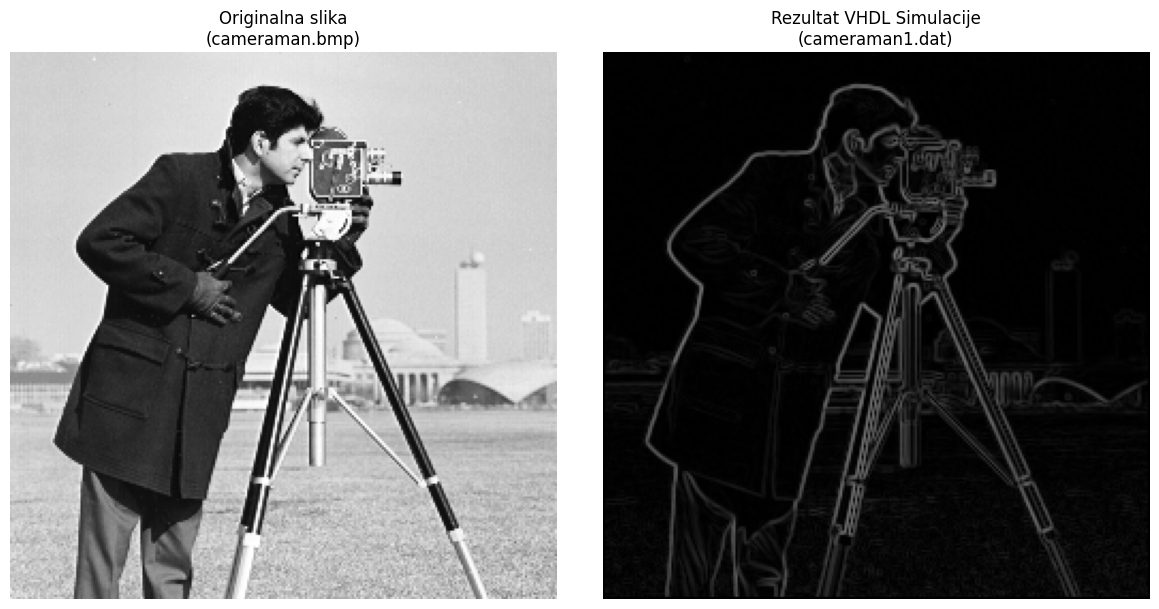

Prikaz zavrsen.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# --- KONFIGURACIJA ---
vhdl_output_file = 'cameraman1.dat' # Rezultat simulacije
original_image_file = 'cameraman.bmp' # Originalna slika

def load_binary_dat_file(filename):
    """
    Ucitava fajl gde je svaki red 8-bitni binarni string (npr. '00101101')
    """
    pixel_data = []
    
    if not os.path.exists(filename):
        print(f"GRESKA: Fajl '{filename}' nije pronadjen!")
        return None

    print(f"Ucitavanje VHDL izlaza: {filename} ...")
    
    with open(filename, 'r') as f:
        lines = f.readlines()
        
    for line_num, line in enumerate(lines):
        line = line.strip()
        if line: # Ako linija nije prazna
            try:
                # int(string, 2) konvertuje binarni string u integer
                val = int(line, 2)
                pixel_data.append(val)
            except ValueError:
                print(f"Upozorenje: Linija {line_num+1} nije validan binarni broj: '{line}'")

    print(f"Ucitano {len(pixel_data)} piksela iz .dat fajla.")
    return np.array(pixel_data, dtype=np.uint8)

# --- GLAVNI DEO ---

# 1. Ucitaj podatke iz VHDL simulacije
vhdl_pixels = load_binary_dat_file(vhdl_output_file)
vhdl_image = None

# Provera i reshape VHDL podataka
if vhdl_pixels is not None:
    expected_size = 256 * 256
    if vhdl_pixels.size == expected_size:
        vhdl_image = vhdl_pixels.reshape((256, 256))
    else:
        print(f"GRESKA VHDL: Ocekivano {expected_size} (256x256), dobijeno {vhdl_pixels.size}")

# 2. Ucitaj originalnu sliku
original_image = None
if os.path.exists(original_image_file):
    print(f"Ucitavanje originalne slike: {original_image_file} ...")
    original_image = mpimg.imread(original_image_file)
    print(f"Originalna slika ucitana. Dimenzije: {original_image.shape}")
else:
    print(f"UPOZORENJE: Originalna slika '{original_image_file}' nije pronadjena.")

# 3. Prikaz (Side-by-Side)
if vhdl_image is not None or original_image is not None:
    # Kreiramo figuru sa dva pod-grafika (1 red, 2 kolone)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # -- Prikaz Originala (Levo) --
    ax_orig = axes[0]
    if original_image is not None:
        # Ako je slika u boji ili grayscale, imshow ce se snaci
        # Postavljamo cmap='gray' za slucaj da je 2D niz
        ax_orig.imshow(original_image, cmap='gray')
        ax_orig.set_title(f"Originalna slika\n({original_image_file})")
    else:
        ax_orig.text(0.5, 0.5, "Fajl nedostaje", ha='center')
        ax_orig.set_title("Original")
    ax_orig.axis('off')

    # -- Prikaz VHDL Rezultata (Desno) --
    ax_vhdl = axes[1]
    if vhdl_image is not None:
        ax_vhdl.imshow(vhdl_image, cmap='gray', vmin=0, vmax=255)
        ax_vhdl.set_title(f"Rezultat VHDL Simulacije\n({vhdl_output_file})")
    else:
        ax_vhdl.text(0.5, 0.5, "Podaci nedostaju ili su pogresni", ha='center')
        ax_vhdl.set_title("VHDL Output")
    ax_vhdl.axis('off')

    plt.tight_layout()
    plt.show()
    print("Prikaz zavrsen.")
else:
    print("Nema podataka za prikaz (ni originala ni simulacije).")

Ucitavanje fajla: test.dat ...
Ucitano 64516 piksela iz test.dat.
Ucitavanje fajla: cameraman1.dat ...
Ucitano 64516 piksela iz cameraman1.dat.


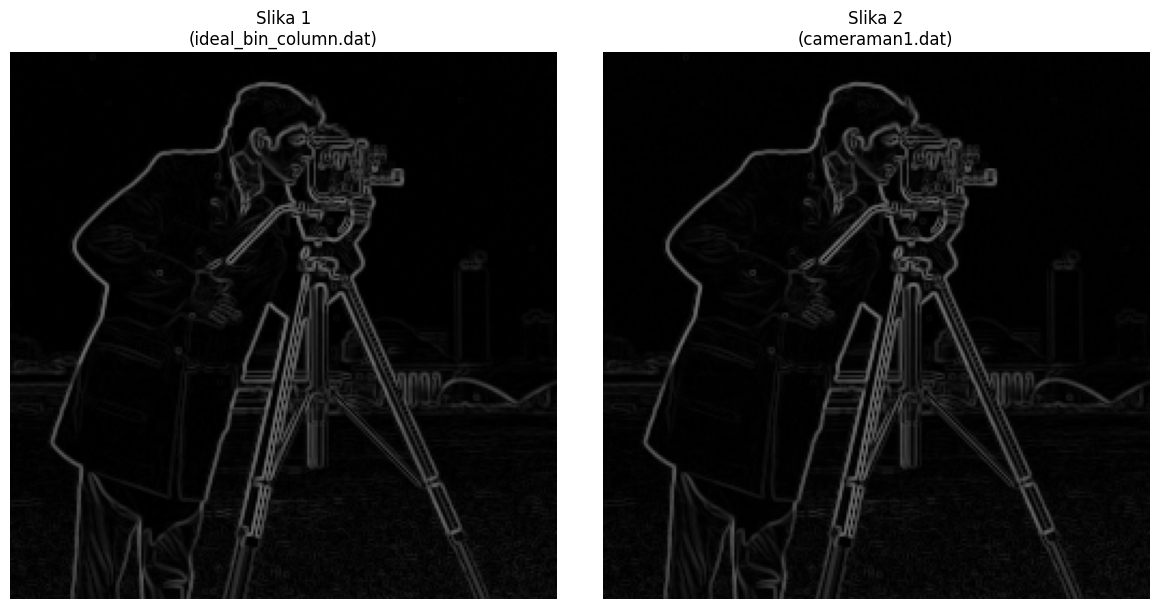

Prikaz zavrsen.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- KONFIGURACIJA ---
# Definisemo imena dva .dat fajla koja zelimo da poredimo
vhdl_file_1 = 'test.dat'        # Prva slika (Levo)
vhdl_file_2 = 'cameraman1.dat'  # Druga slika (Desno)

# Ocekivane dimenzije slike (za reshape)
IMG_HEIGHT = 254
IMG_WIDTH = 254

def load_binary_dat_file(filename):
    """
    Ucitava fajl gde je svaki red 8-bitni binarni string (npr. '00101101')
    """
    pixel_data = []
    
    if not os.path.exists(filename):
        print(f"GRESKA: Fajl '{filename}' nije pronadjen!")
        return None

    print(f"Ucitavanje fajla: {filename} ...")
    
    with open(filename, 'r') as f:
        lines = f.readlines()
        
    for line_num, line in enumerate(lines):
        line = line.strip()
        if line: # Ako linija nije prazna
            try:
                # int(string, 2) konvertuje binarni string u integer
                val = int(line, 2)
                pixel_data.append(val)
            except ValueError:
                print(f"Upozorenje: Linija {line_num+1} u '{filename}' nije validan binarni broj: '{line}'")

    print(f"Ucitano {len(pixel_data)} piksela iz {filename}.")
    return np.array(pixel_data, dtype=np.uint8)

def process_vhdl_data(raw_data, filename):
    """
    Pomocna funkcija koja proverava velicinu niza i reshape-uje ga u sliku.
    """
    if raw_data is None:
        return None
        
    expected_size = IMG_HEIGHT * IMG_WIDTH
    
    if raw_data.size == expected_size:
        return raw_data.reshape((IMG_HEIGHT, IMG_WIDTH))
    else:
        print(f"GRESKA DIMENZIJA ({filename}): Ocekivano {expected_size} ({IMG_WIDTH}x{IMG_HEIGHT}), dobijeno {raw_data.size}")
        return None

# --- GLAVNI DEO ---

# 1. Ucitaj podatke za prvu sliku (test.dat)
raw_pixels_1 = load_binary_dat_file(vhdl_file_1)
image_1 = process_vhdl_data(raw_pixels_1, vhdl_file_1)

# 2. Ucitaj podatke za drugu sliku (cameraman1.dat)
raw_pixels_2 = load_binary_dat_file(vhdl_file_2)
image_2 = process_vhdl_data(raw_pixels_2, vhdl_file_2)


# 3. Prikaz (Side-by-Side)
if image_1 is not None or image_2 is not None:
    # Kreiramo figuru sa dva pod-grafika (1 red, 2 kolone)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # -- Prikaz Prve Slike (Levo) --
    ax1 = axes[0]
    if image_1 is not None:
        ax1.imshow(image_1, cmap='gray', vmin=0, vmax=255)
        ax1.set_title("Slika 1\n(ideal_bin_column.dat)")
    else:
        ax1.text(0.5, 0.5, "Podaci nedostaju", ha='center')
        ax1.set_title(f"Greska: {vhdl_file_1}")
    ax1.axis('off')

    # -- Prikaz Druge Slike (Desno) --
    ax2 = axes[1]
    if image_2 is not None:
        ax2.imshow(image_2, cmap='gray', vmin=0, vmax=255)
        ax2.set_title(f"Slika 2\n({vhdl_file_2})")
    else:
        ax2.text(0.5, 0.5, "Podaci nedostaju", ha='center')
        ax2.set_title(f"Greska: {vhdl_file_2}")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()
    print("Prikaz zavrsen.")
else:
    print("Nijedan fajl nije uspesno ucitan.")

In [16]:
import os

# --- KONFIGURACIJA ---
file_1 = 'test.dat'
file_2 = 'cameraman1.dat'

# Kolika je dozvoljena razlika? (0, 1, 2 su OK -> stavljamo 2)
TOLERANCE = 2 

def compare_files_with_tolerance(f1_path, f2_path):
    if not os.path.exists(f1_path) or not os.path.exists(f2_path):
        print("GRESKA: Jedan ili oba fajla ne postoje.")
        return

    print(f"Poredim fajlove uz toleranciju +/- {TOLERANCE}:")
    print(f" 1. {f1_path}")
    print(f" 2. {f2_path}")
    print("-" * 40)

    try:
        with open(f1_path, 'r') as f1, open(f2_path, 'r') as f2:
            # Ucitavamo linije, sklanjamo whitespace i prazne redove
            lines1 = [line.strip() for line in f1.readlines() if line.strip()]
            lines2 = [line.strip() for line in f2.readlines() if line.strip()]
    except Exception as e:
        print(f"Greska pri citanju fajlova: {e}")
        return

    len1 = len(lines1)
    len2 = len(lines2)
    min_len = min(len1, len2)
    
    error_count = 0

    print("Provera linija...")
    
    # Poredjenje red po red
    for i in range(min_len):
        try:
            # Konvertujemo binarni string u integer
            val1 = int(lines1[i], 2)
            val2 = int(lines2[i], 2)
            
            # Izracunavamo apsolutnu razliku
            diff = abs(val1 - val2)

            # --- KLJUCNA PROMENA ---
            # Ako je razlika veca od 2, to je greska. (0, 1, 2 su OK)
            if diff > TOLERANCE:
                error_count += 1
                
                # Ispisujemo prvih 5 gresaka detaljno
                if error_count <= 5:
                    print(f"[!] Greska na liniji {i+1}:")
                    print(f"    Fajl 1: {val1} ({lines1[i]})")
                    print(f"    Fajl 2: {val2} ({lines2[i]})")
                    print(f"    Razlika: {diff} (Dozvoljeno: {TOLERANCE})")
                    print("-" * 20)

        except ValueError:
            print(f"GRESKA FORMATA na liniji {i+1}: Nije validan binarni broj.")
            error_count += 1

    # Dodajemo razliku u duzini fajlova kao greske
    length_diff = abs(len1 - len2)
    total_errors = error_count + length_diff

    # --- REZULTAT ---
    print("\n" + "=" * 40)
    print(f"Ukupno linija (Fajl 1): {len1}")
    print(f"Ukupno linija (Fajl 2): {len2}")
    print("=" * 40)
    
    if total_errors == 0:
        print(f"✅ USPEH: Fajlovi su isti.")
    else:
        print(f"❌ PRONADJENO RAZLIKA: {total_errors}")
        print(f"   (Znacajnih razlika > {TOLERANCE}: {error_count})")
        if length_diff > 0:
            print(f"   (Razlika u broju linija: {length_diff})")

# Pokretanje
compare_files_with_tolerance(file_1, file_2)

Poredim fajlove uz toleranciju +/- 2:
 1. test.dat
 2. cameraman1.dat
----------------------------------------
Provera linija...

Ukupno linija (Fajl 1): 64516
Ukupno linija (Fajl 2): 64516
✅ USPEH: Fajlovi su isti.


In [ ]:
import matplotlib.pyplot as plt

IMAGE_SIZE = 256



# OVDE DODATI KOD ZA POREDJENJE, ISKORISTITI KOD IZ PRVE FAZE

# Za sada samo poredjenje sa ulaynosm slikom ucitanom iz bmp fajla

swIm = plt.imread('cameraman.bmp')
plt.imshow(swIm, cmap='gray', vmin=0, vmax=255)
plt.title("SW original image")
plt.show()
